In [25]:
import numpy as np 
from matplotlib import pyplot as plt #ignore
from astroML.datasets import generate_mu_z
from sklearn.linear_model import LinearRegression
from astroML.linear_model import PolynomialRegression

/opt/anaconda3/lib/python3.13/site-packages/astroML/linear_model/linear_regression_errors.py:10: UserWarning: LinearRegressionwithErrors requires PyMC3 to be installed
  warnings.warn('LinearRegressionwithErrors requires PyMC3 to be installed')


(35.0, 50.0)

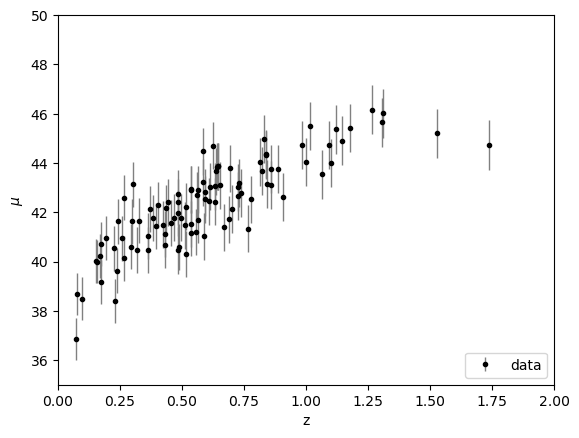

In [7]:
z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234) # YOU CANNOT CHANGE THIS

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50)

## Linear regression

In [43]:
theta0=0.4
theta1=0.4

X = z_sample.reshape(-1,1)
y = mu_sample

lin_reg = LinearRegression()
lin_reg.fit(X, y, sample_weight=1.0)

theta0 = lin_reg.intercept_
theta1 = lin_reg.coef_[0]

y_pred_lin = lin_reg.predict(z_test.reshape(-1,1))

print(theta0, theta1)

39.56505554722625 4.647118479591295


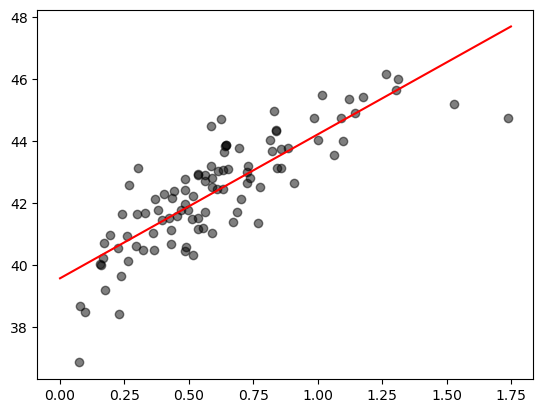

In [44]:
z_test = np.linspace(0, 1.75, 100)

plt.scatter (z_sample, mu_sample, c='black', alpha=0.5)
plt.plot(z_test, y_pred_lin, c='red')
plt.show()

## Polynomial regression

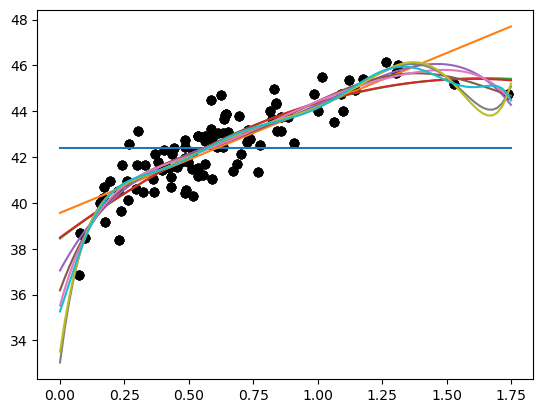

In [49]:
degree_max=10
colors = [
    'tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 
    'tab:brown', 'tab:pink', 'tab:gray', 'tab:olive', 'tab:cyan'
]

training_err = np.zeros(degree_max)
crossval_err = np.zeros(degree_max)

for degree in range(degree_max):
    model = PolynomialRegression(degree) # fit 3rd degree polynomial
    model.fit(X, y)

    y_pred_poly = model.predict(z_test.reshape(-1,1))

    plt.scatter(z_sample, mu_sample, c='black', alpha=0.5)
    plt.plot(z_test, y_pred_poly, c=colors[degree])

    #training_err[i] = np.sqrt(np.sum((np.polyval(p, x) - y) ** 2) / len(y))
    #crossval_err[i] = np.sqrt(np.sum((np.polyval(p, x_cv) - y_cv) ** 2) / len(y_cv))


plt.show()